In [1]:
import vireoSNP
from vireoSNP import BinomMixtureVB
from vireoSNP.plot.base_plot import heat_matrix
import numpy as np
from scipy import sparse
from scipy.io import mmread
import matplotlib.pyplot as plt
import pandas as pd

print(vireoSNP.__version__)

0.5.9


In [17]:
# Assign clones with vireoSNP
# Here we assign cells to clones based on mtDNA mutations found by MQuad. Although there are only 2 variants found due to sparsity of 10x dataset, vireo still confidently assigns a good proportion of cells into 2 clones.

# read in output from MQuad

AD = mmread("../../../results/standalone/mquad/TNBC1/passed_ad.mtx").tocsc()
DP = mmread("../../../results/standalone/mquad/TNBC1/passed_dp.mtx").tocsc()

AD.shape, DP.shape

((2, 1097), (2, 1097))

In [18]:
# we have already run the estimate of the number of donors at this point and we fix it
_model = BinomMixtureVB(n_var=len(AD.getnnz(axis=1)), n_cell=len(AD.getnnz(axis=0)), n_donor=3)
_model.fit(AD, DP, min_iter=30, n_init=300)

# save the object
modelCA = _model

In [19]:
# the ID_prob slot holds the probability of being either one of the n_donor fixed
for i in modelCA.ID_prob:
    print(i)

[7.43342166e-01 1.24937479e-06 2.56656585e-01]
[0.50094148 0.00401317 0.49504535]
[6.70161557e-01 8.61810096e-05 3.29752262e-01]
[0.51637416 0.05122059 0.43240525]
[3.27365892e-01 3.88573469e-07 6.72633720e-01]
[5.94547117e-01 6.83402547e-08 4.05452815e-01]
[0.28427223 0.00546763 0.71026014]
[7.34242669e-01 4.86660580e-10 2.65757331e-01]
[0.51637416 0.05122059 0.43240525]
[5.21577761e-16 1.00000000e+00 2.10301161e-12]
[7.74989771e-01 7.09823704e-07 2.25009519e-01]
[8.02546948e-01 9.10132744e-06 1.97443951e-01]
[0.44425833 0.00075353 0.55498814]
[0.32246851 0.00144201 0.67608949]
[6.34092780e-01 5.11445539e-07 3.65906709e-01]
[6.71907853e-01 3.80287959e-06 3.28088345e-01]
[5.94211260e-01 1.20518768e-07 4.05788619e-01]
[7.00698759e-01 3.75092288e-11 2.99301241e-01]
[0.4313317  0.13853656 0.43013174]
[0.50094148 0.00401317 0.49504535]
[3.33839372e-01 2.62351731e-12 6.66160628e-01]
[0.50094148 0.00401317 0.49504535]
[1.14476105e-01 3.74032928e-14 8.85523895e-01]
[6.36996864e-01 3.09864948e

In [20]:
for i in modelCA.ELBO_inits:
    print(i)

-1920.1822990238766
-1920.1831504503361
-1920.1824945850226
-1920.182539655611
-1920.185247791646
-1920.2160765601693
-1920.1839556431842
-1920.1829741242423
-1920.1823855150715
-1920.1852033404384
-1920.1823705574916
-1920.1852327858396
-1920.182338016537
-1920.1823453002198
-1920.1838517967635
-1920.1827246298458
-1920.182263099838
-1920.189467253797
-1920.21383439371
-1920.1822738997266
-1920.1895371361907
-1920.1840748059662
-1920.1857008782445
-1920.1823983557647
-1920.1822648918446
-1920.1824090194382
-1920.182758616289
-1920.182297224022
-1920.1822720058371
-1920.183064602952
-1920.1824485272996
-1920.1822639443126
-1920.1826704450432
-1920.1826410929039
-1920.18378792057
-1920.1843017199117
-1920.182341640792
-1920.182362033313
-1920.1824315319554
-1920.1825463188834
-1920.1822782935583
-1920.1826334043521
-1920.1822697697303
-1920.1824229852186
-1920.1828065863865
-1920.183532687728
-1920.1873464999321
-1920.183092620116
-1920.1826450489189
-1920.1822635111444
-1920.1823265097

In [21]:
# table for the allelic ratio per variant per clone id
for i in modelCA.beta_mu:
    print(i)

[0.00028051 0.24731803 0.00097652]
[0.0939686  0.12866586 0.23702375]


In [22]:
modelCA

In [23]:
# load the ordered barcodes from the cells this should be equivalent to the input of cellsnp
with open('../../../data/aaronkwc-MQuad_paper_reproduced_results-d9de94f/droplet_based_data/TNBC1_data/cellsnp/cellSNP.samples.tsv', 'r') as f:
    sample_id = f.read().splitlines()

In [24]:
# laod the barcode annotation in present/needed
with open('../../../data/aaronkwc-MQuad_paper_reproduced_results-d9de94f/droplet_based_data/TNBC1_data/tumor_label.txt', 'r') as f:
    tumor = f.read().splitlines()

In [25]:
# for each ID_prop avaluate which one is the most likely and assigni the barcode
conf = []
for i in modelCA.ID_prob:
    if max(i) >= 0.8:
        conf.append('True')
    else:
        conf.append('False')
        
clone_id = np.argmax(modelCA.ID_prob, axis=1)

In [26]:
clone_id

array([0, 0, 0, ..., 2, 0, 2], shape=(1097,))

In [27]:
# define the final metadata with all the info available
clones_df = pd.DataFrame(data={'sample_id':sample_id, 'clone_id':clone_id, 'confident':conf,'tumor':tumor})
clones_df = clones_df.rename({0: 'sample_id', 1: 'clone_id', 2:'confident', 3:'tumor'}, axis='columns')
clones_df

,sample_id,clone_id,confident,tumor
0,AAACCTGCACCTTGTC-1,0,False,T
1,AAACGGGAGTCCTCCT-1,0,False,N
2,AAACGGGTCCAGAGGA-1,0,False,T
3,AAAGATGCAGTTTACG-1,0,False,T
4,AAAGCAACAGGAATGC-1,2,False,T
...,...,...,...,...
1092,TTTATGCTCCTCATTA-1,0,True,T
1093,TTTATGCTCTGTTGAG-1,0,False,T
1094,TTTCCTCTCGGAAACG-1,2,False,T
1095,TTTGCGCCAATCACAC-1,0,False,T


In [38]:
ELBO_matrix = _model.ELBO_inits
ELBO_matrix.shape

test = []
for i in modelCA.ELBO_inits:
    test.append(i)

In [39]:
test

[np.float64(-1920.1822990238766),
 np.float64(-1920.1831504503361),
 np.float64(-1920.1824945850226),
 np.float64(-1920.182539655611),
 np.float64(-1920.185247791646),
 np.float64(-1920.2160765601693),
 np.float64(-1920.1839556431842),
 np.float64(-1920.1829741242423),
 np.float64(-1920.1823855150715),
 np.float64(-1920.1852033404384),
 np.float64(-1920.1823705574916),
 np.float64(-1920.1852327858396),
 np.float64(-1920.182338016537),
 np.float64(-1920.1823453002198),
 np.float64(-1920.1838517967635),
 np.float64(-1920.1827246298458),
 np.float64(-1920.182263099838),
 np.float64(-1920.189467253797),
 np.float64(-1920.21383439371),
 np.float64(-1920.1822738997266),
 np.float64(-1920.1895371361907),
 np.float64(-1920.1840748059662),
 np.float64(-1920.1857008782445),
 np.float64(-1920.1823983557647),
 np.float64(-1920.1822648918446),
 np.float64(-1920.1824090194382),
 np.float64(-1920.182758616289),
 np.float64(-1920.182297224022),
 np.float64(-1920.1822720058371),
 np.float64(-1920.18306

In [10]:
# save clone_id for later use
clones_df.to_csv('../../../../data/MQuad_test/TNBC1/clones_df.csv')

In [41]:
# plotting
def plot_figure_5b_assignment(modelCA):
    im = heat_matrix(modelCA.ID_prob, cmap="Oranges", alpha=0.8,
                 display_value=False, row_sort=True, interpolation = 'none')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title("Assignment probability")
    plt.xlabel("Clone")
    plt.ylabel("%d cells" %(modelCA.n_cell))
    plt.xticks(range(modelCA.n_donor))
    plt.tight_layout()

def plot_figure_5b_AF(modelCA):
    im = heat_matrix(modelCA.beta_mu, cmap="Blues", alpha=0.8, 
                 display_value=False, row_sort=True, interpolation='none')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title("Mean allelic ratio")
    plt.xlabel("Clone")
    plt.ylabel("%d SNPs" %(modelCA.n_var))
    plt.xticks(range(modelCA.n_donor))
    plt.tight_layout()

NameError: name 'plot_figure_5c' is not defined

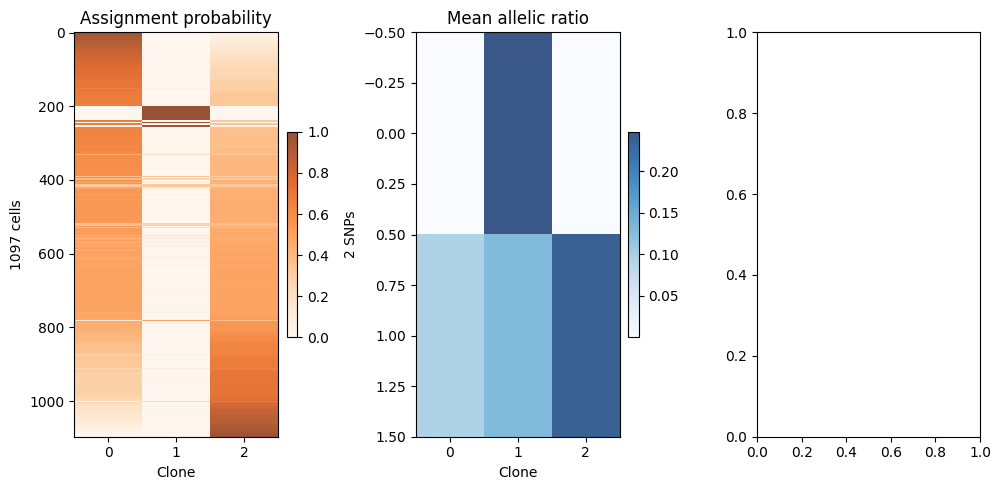

In [42]:
fig = plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plot_figure_5b_assignment(modelCA)

plt.subplot(1,3,2)
plot_figure_5b_AF(modelCA)

ax=plt.subplot(1,3,3)
plot_figure_5c(ax)